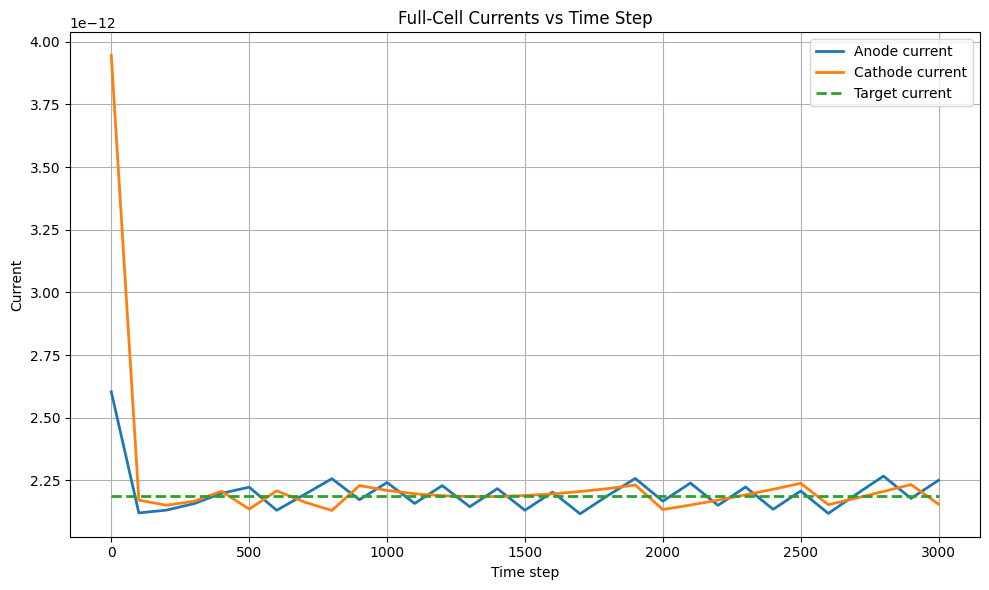

In [3]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Load text file ---
# Replace with your actual file name
file_path = "bin/full_cell_output.txt"

with open(file_path, 'r') as f:
    lines = f.readlines()

# --- Step 2: Parse each line using regex ---
data = []
pattern = re.compile(
    r"timestep:\s*(\d+).*?Anode current\s*=\s*([-eE0-9.]+),\s*Cathode current\s*=\s*([-eE0-9.]+),.*?Target Current\s*=\s*([-eE0-9.]+)"
)

for line in lines:
    match = pattern.search(line)
    if match:
        timestep = int(match.group(1))
        anode = abs(float(match.group(2)))  # absolute value
        cathode = float(match.group(3))
        target = float(match.group(4))
        data.append((timestep, anode, cathode, target))

# --- Step 3: Convert to DataFrame ---
df = pd.DataFrame(data, columns=["Timestep", "Anode", "Cathode", "Target"])

# df = df[df["Timestep"] != 0] # Remove timestep 0


# --- Step 4: Plot ---
plt.figure(figsize=(10,6))
plt.plot(df["Timestep"], df["Anode"], label="Anode current", linewidth=2)
plt.plot(df["Timestep"], df["Cathode"], label="Cathode current", linewidth=2)
plt.plot(df["Timestep"], df["Target"], '--', label="Target current", linewidth=2)

plt.xlabel("Time step")
plt.ylabel("Current")
plt.title("Full-Cell Currents vs Time Step")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
